In [35]:
#%matplotlib qt5

In [36]:
import time
import numpy as np
import pykep as pk
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

In [37]:
# Define orbit parameters from the table
orbits = {
    'A': {'eccentricity': 0.1, 'semi_major_axis': 7000},  # km
    'B': {'eccentricity': 0.9, 'semi_major_axis': 70000}, # km  
    'C': {'eccentricity': 2.0, 'semi_major_axis': -7000},  # km (hyperbolic orbit)
    'D': {'eccentricity': 0.0, 'semi_major_axis': 7000} ,  # km (circular orbit)
    'E': {'eccentricity': 1.0, 'semi_major_axis': -7000}  # km (parabolic orbit)
}

mu = 3.986e5 # km^3/s^2

**(a)** Select two numerical algorithms:  
I. Runge–Kutta 4th order, and  
II. A higher-order method (e.g., RK 8(9), RK–Nystrom).

The two numerical algorithms selected are:

I. **Runge–Kutta 4th Order (RK4)** – a widely used, fixed-step integration method that provides a good balance between accuracy and computational cost.  
II. **Runge–Kutta 8(9) Method (Dormand–Prince 8/9)** – a higher-order adaptive step-size algorithm that achieves greater accuracy and efficiency, particularly useful for long-term orbital integrations.

**(b)** Justify your selection, i.e., what criteria were used (e.g., source, confidence, suggestions, quality/speed of the algorithm).

The selection was based on the following criteria:

- **Accuracy and Reliability:** The Runge–Kutta 4th Order (RK4) method is a standard, well-tested algorithm known for its stability and accuracy in solving ordinary differential equations. It serves as a reliable baseline for comparison.
- **Efficiency and Precision:** The Runge–Kutta 8(9) (Dormand–Prince) method provides higher accuracy with adaptive step-size control, allowing efficient computation while maintaining precision over long integrations.
- **Source and Confidence:** Both methods are widely documented and implemented in reputable numerical libraries (e.g., MATLAB, SciPy), ensuring confidence in their performance and correctness.
- **Comparative Value:** Using RK4 alongside a higher-order method allows evaluation of trade-offs between computational cost and accuracy, particularly in orbital mechanics problems where cumulative numerical errors can be significant.

**(c)** Use orbit B, the exact solution of the central-body problem, and integrate the equations of motion of a satellite around a point-like Earth to study numerical convergence using **Algorithm I**. In this case you can consider the problem in only two dimensions.

i. Integrate with $\Delta t = 100 \ \mathrm{s}$ for 5 orbits and record the time of computation. If using a variable-step algorithm, attempt to limit the step size to approximate a constant step. If not possible, determine the minimum step required for a given accuracy goal.  
ii. Plot the numerical and analytical trajectories.  
iii. Plot $\Delta r(t)$ and $\Delta\theta(t)$ representing the differences between the analytical trajectory using Kepler’s equation and the numerical solution for each instant of time.  
iv. Plot the position error $|\mathbf{r}_\mathrm{num}(t) − \mathbf{r}_\mathrm{ellipt}(t)|$.  
v. Compare error measures (iii) and (iv), and justify which is more appropriate.

In [38]:
def two_body_ode(t, state):
    """Two-body orbital dynamics ODE"""
    r_vec, v_vec = state[:2], state[2:]
    r_vec_norm = np.sqrt(r_vec.T @ r_vec)
    a_vec = -mu * r_vec / r_vec_norm**3
    return np.concatenate([v_vec, a_vec])

def analytical_solution(t, a, e, mu=mu):
    """
    Planar Keplerian propagation using PyKEP with the notebook's unit system (km, s).
    Assumes i = 0, Ω = 0, ω = 0 and starts at periapsis at t = 0.
    """
    # Keplerian elements expected by PyKEP: [a, e, i, Ω, ω, M]
    # Start at periapsis -> mean anomaly M0 = 0
    el0 = [a, e, 0.0, 0.0, 0.0, 0.0]

    # Elements -> initial Cartesian state (units consistent with mu)
    r0, v0 = pk.par2ic(el0, mu)

    # Keplerian propagation for time t (seconds); do NOT rescale time
    rf, vf = pk.propagate_lagrangian(r0, v0, t, mu)

    # For a planar orbit with i = Ω = ω = 0, true anomaly is atan2(y, x)
    x, y, z = rf
    theta = np.arctan2(y, x)

    r_vec = np.array([x, y])
    r_vec_norm = np.linalg.norm(r_vec)
    
    return x, y, theta, r_vec, r_vec_norm

In [39]:
dt = 10  # time step [s]
orbit_to_use = 'B'

a = orbits[orbit_to_use]['semi_major_axis']  # km
e = orbits[orbit_to_use]['eccentricity']

# Initial conditions at perigee (OTHERWISE THE ANALYTICAL SOLUTION IS NOT ALIGNED)
theta0 = 0
p = a * (1 - e**2)  # km
r0 = p / (1 + e * np.cos(theta0))  # km
v0 = np.sqrt(mu * (2/r0 - 1/a))  # km/s
state0 = np.array([r0, 0, 0, v0])

# === TIME SETTINGS ===
n_orbits = 5
T = 2 * np.pi * np.sqrt(np.abs(a) ** 3 / mu)  # orbital period [s]
t_final = n_orbits * T
N = int(t_final / dt)
print(f"Orbital period: {T/3600:.2f} hours | Total simulation time: {t_final/3600:.2f} hours | Number of time steps: {N}")

Orbital period: 51.20 hours | Total simulation time: 255.99 hours | Number of time steps: 92156


In [40]:
def r_vecs2several_quantities(r_vec):
    x = r_vec[:, 0]
    y = r_vec[:, 1]
    r_vec_norm = np.sqrt(x**2 + y**2)
    theta = np.arctan2(y, x)
    return x, y, theta, r_vec, r_vec_norm

In [41]:
# Cartesian solutions
t_vals = np.linspace(0, N * dt, N + 1)

states_cartesian_rk4 = np.zeros((N + 1, 4))
states_cartesian_rk4[0] = state0
start_time_cartesian_rk4 = time.time()
for i in range(N):
    solution = solve_ivp(two_body_ode, [t_vals[i], t_vals[i + 1]], states_cartesian_rk4[i], method='DOP853')
    states_cartesian_rk4[i + 1] = solution.y[:, -1]
elapsed_time_cartesian_rk4 = time.time() - start_time_cartesian_rk4
x_cartesian_rk4, y_cartesian_rk4, theta_cartesian_rk4, r_vec_cartesian_rk4, r_vec_norm_cartesian_rk4 = r_vecs2several_quantities(states_cartesian_rk4[:, :2])

states_cartesian_adams = np.zeros((N + 1, 4))
states_cartesian_adams[0] = state0
start_time_cartesian_adams = time.time()
for i in range(N):
    solution = solve_ivp(two_body_ode, [t_vals[i], t_vals[i + 1]], states_cartesian_adams[i], method='LSODA')
    states_cartesian_adams[i + 1] = solution.y[:, -1]
elapsed_time_cartesian_adams = time.time() - start_time_cartesian_adams
x_cartesian_adams, y_cartesian_adams, theta_cartesian_adams, r_vec_cartesian_adams, r_vec_norm_cartesian_adams = r_vecs2several_quantities(states_cartesian_adams[:, :2])

x_cartesian_analytical = np.zeros(N + 1)
y_cartesian_analytical = np.zeros(N + 1)
theta_cartesian_analytical = np.zeros(N + 1)
r_vec_cartesian_analytical = np.zeros((N + 1, 2))
r_vec_norm_cartesian_analytical = np.zeros(N + 1)
for i in range(N + 1):
    x_cartesian_analytical[i], y_cartesian_analytical[i], theta_cartesian_analytical[i], r_vec_cartesian_analytical[i], r_vec_norm_cartesian_analytical[i] = analytical_solution(t_vals[i], a, e)

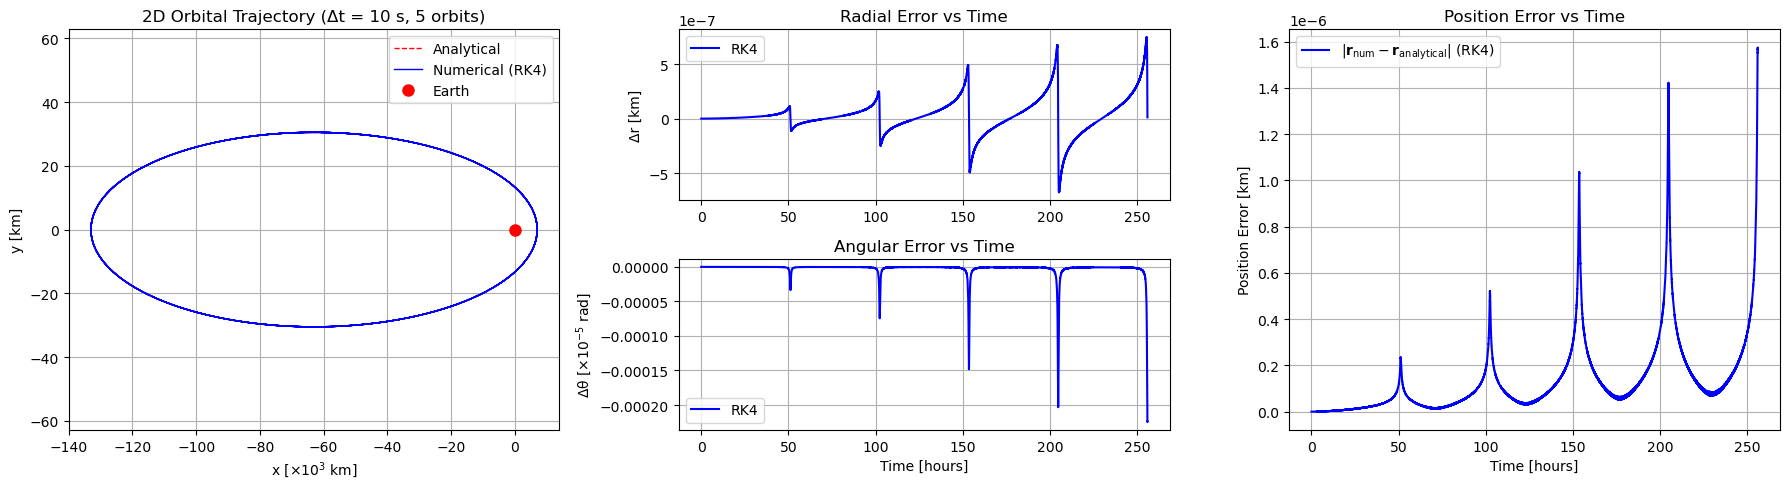

In [42]:
fig = plt.figure(figsize=(18, 5))
gs = fig.add_gridspec(2, 3)  # 2 rows, 3 columns total

# --- Plot 1: Trajectory comparison (spans both rows in column 0)
ax1 = fig.add_subplot(gs[:, 0])
ax1.plot(x_cartesian_analytical / 1e3, y_cartesian_analytical / 1e3, '--', label='Analytical', color='red', linewidth=1)
ax1.plot(x_cartesian_rk4 / 1e3, y_cartesian_rk4 / 1e3, label='Numerical (RK4)', color='blue', linewidth=1)
# ax1.plot(x_cartesian_adams / 1e3, y_cartesian_adams / 1e3, label='Numerical (Adams)', color='green', linewidth=1)
ax1.plot(0, 0, 'ro', label='Earth', markersize=8)
ax1.set_xlabel('x [$\\times 10^3$ km]')
ax1.set_ylabel('y [km]')
ax1.set_title(f'2D Orbital Trajectory (Δt = {dt} s, {n_orbits} orbits)')
ax1.legend()
ax1.axis('equal')
ax1.grid(True)

# --- Plot 2a: Δr vs Time (top-right)
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(t_vals / 3600, r_vec_norm_cartesian_rk4 - r_vec_norm_cartesian_analytical, label='RK4', color='blue')
# ax2.plot(t_vals / 3600, r_vec_norm_cartesian_adams - r_vec_norm_cartesian_analytical, label='Adams', color='green')
ax2.set_ylabel('Δr [km]')
ax2.set_title('Radial Error vs Time')
ax2.legend()
ax2.grid(True)

# --- Plot 2b: Δθ vs Time (bottom-right)
ax3 = fig.add_subplot(gs[1, 1])
ax3.plot(t_vals / 3600, (np.mod(theta_cartesian_rk4 - theta_cartesian_analytical + np.pi, 2*np.pi) - np.pi) * 1e6, label='RK4', color='blue')
# ax3.plot(t_vals / 3600, (np.mod(theta_cartesian_adams - theta_cartesian_analytical + np.pi, 2*np.pi) - np.pi) * 1e5, label='Adams', color='green')
ax3.set_xlabel('Time [hours]')
ax3.set_ylabel('Δθ [$\\times 10^{-5}$ rad]')
ax3.set_title('Angular Error vs Time')
ax3.legend()
ax3.grid(True)

# --- Plot 3: Position error vs Time (spans both rows in column 2)
ax4 = fig.add_subplot(gs[:, 2])
ax4.plot(t_vals / 3600, np.linalg.norm(r_vec_cartesian_rk4 - r_vec_cartesian_analytical, axis=1),
         label=r"$|\mathbf{r}_\mathrm{num} - \mathbf{r}_\mathrm{analytical}|$ (RK4)", color='blue')
# ax4.plot(t_vals / 3600, np.linalg.norm(r_vec_cartesian_adams - r_vec_cartesian_analytical, axis=1),
#          label=r"$|\mathbf{r}_\mathrm{num} - \mathbf{r}_\mathrm{analytical}|$ (Adams)", color='green')
ax4.set_xlabel('Time [hours]')
ax4.set_ylabel('Position Error [km]')
ax4.set_title('Position Error vs Time')
ax4.legend()
ax4.grid(True)

# --- Final layout
plt.tight_layout()
plt.show()

In [43]:
def cartesian_coordinates2ks_state(cartesian_coordinates):
    """
    Transform Cartesian coordinates to Kustaanheimo-Stiefel state
    """
    x1, x2 = cartesian_coordinates
    x3 = 0 # TODO: Add z coordinate
    x_norm = np.sqrt(x1**2 + x2**2 + x3**2)
    
    # From Low-trush trajectory optimization using the kustaa-stiefel transformation Kevin Tracy and Zachary Manchester
    # TODO: compactify with vectorization
    y1 = 0.1
    y4 = np.sqrt(0.5 * (x_norm + x1) - y1 ** 2)
    y2 = (x2 * y1 + x3 * y4) / (x_norm + x1)
    y3 = (x3 * y1 - x2 * y4) / (x_norm + x1)
    ks_state = np.array([y1, y2, y3, y4])

    return ks_state

def cartesian_velocity2ks_state_dot(cartesian_velocity, ks_state):
    """
    Transform Cartesian velocity to Kustaanheimo-Stiefel fictitious velocity
    """
    x1_dot, x2_dot = cartesian_velocity
    x3_dot = 0 # TODO: Add z coordinate
    y1, y2, y3, y4 = ks_state
    
    # FromLow-trush trajectory optimization using the kustaa-stiefel transformation Kevin Tracy and Zachary Manchester
    # TODO: compactify with vectorization
    y1_dot = 0.5 * (y1 * x1_dot + y2 * x2_dot + y3 * x3_dot)
    y2_dot = 0.5 * (-y2 * x1_dot + y1 * x2_dot + y4 * x3_dot)
    y3_dot = 0.5 * (-y3 * x1_dot - y4 * x2_dot + y1 * x3_dot)
    y4_dot = 0.5 * (y4 * x1_dot - y3 * x2_dot + y2 * x3_dot)
    ks_state_dot = np.array([y1_dot, y2_dot, y3_dot, y4_dot])

    return ks_state_dot

def L_matrix(ks_state):
    """
    Compute the L matrix from the Kustaanheimo-Stiefel state
    """
    y1, y2, y3, y4 = ks_state
    
    L = np.array([[y1, -y2, -y3, y4],
                  [y2, y1, -y4, -y3],
                  [y3, y4, y1, y2],
                  [y4, -y3, y2, -y1]])
    return L
    
def ks_state2cartesian_coordinates(ks_state):
    """
    Transform Kustaanheimo-Stiefel state to Cartesian coordinates
    """
    L = L_matrix(ks_state)
    cartesian_coordinates = L @ ks_state

    return cartesian_coordinates[:3]

def ks_ode_system(t, ks_augmented_state):
    """
    Kustaanheimo-Stiefel transformed ODE system for two-body problem
    """
    ks_state, ks_state_dot = ks_augmented_state[:4], ks_augmented_state[4:8]
    h = (mu - 2 * ks_state_dot.T @ ks_state_dot) / (ks_state.T @ ks_state)
    ks_state_ddot = - h / 2 * ks_state
    
    return np.concatenate([ks_state_dot, ks_state_ddot])

In [44]:
# Initial conditions at perigee
ks_state0 = cartesian_coordinates2ks_state(state0[:2])
ks_state_dot0 = cartesian_velocity2ks_state_dot(state0[2:], ks_state0)
ks_augmented_state0 = np.concatenate([ks_state0, ks_state_dot0])

In [45]:
# KS solution
ds = dt / a
s_vals = np.linspace(0, N * ds, N + 1)

ks_augmented_states_ks_rk4 = np.zeros((N + 1, 8))
ks_augmented_states_ks_rk4[0] = ks_augmented_state0
r_vec_ks_rk4 = np.zeros((N + 1, 2))
r_vec_ks_rk4[0] = ks_state2cartesian_coordinates(ks_augmented_states_ks_rk4[0][:4])[:2]
start_time_ks_rk4 = time.time()
for i in range(N):
    solution = solve_ivp(ks_ode_system, [s_vals[i], s_vals[i + 1]], ks_augmented_states_ks_rk4[i], method='DOP853')
    ks_augmented_states_ks_rk4[i + 1] = solution.y[:, -1]
    r_vec_ks_rk4[i + 1] = ks_state2cartesian_coordinates(ks_augmented_states_ks_rk4[i + 1][:4])[:2]
elapsed_time_ks_rk4 = time.time() - start_time_ks_rk4
x_ks_rk4, y_ks_rk4, theta_ks_rk4, r_vec_ks_rk4, r_vec_norm_ks_rk4 = r_vecs2several_quantities(r_vec_ks_rk4)

ks_augmented_states_ks_adams = np.zeros((N + 1, 8))
ks_augmented_states_ks_adams[0] = ks_augmented_state0
r_vec_ks_adams = np.zeros((N + 1, 2))
r_vec_ks_adams[0] = ks_state2cartesian_coordinates(ks_augmented_states_ks_adams[0][:4])[:2]
start_time_ks_adams = time.time()
for i in range(N):
    solution = solve_ivp(ks_ode_system, [s_vals[i], s_vals[i + 1]], ks_augmented_states_ks_adams[i], method='LSODA')
    ks_augmented_states_ks_adams[i + 1] = solution.y[:, -1]
    r_vec_ks_adams[i + 1] = ks_state2cartesian_coordinates(ks_augmented_states_ks_adams[i + 1][:4])[:2]
elapsed_time_ks_adams = time.time() - start_time_ks_adams
x_ks_adams, y_ks_adams, theta_ks_adams, r_vec_ks_adams, r_vec_norm_ks_adams = r_vecs2several_quantities(r_vec_ks_adams)

x_ks_analytical = np.zeros(N + 1)
y_ks_analytical = np.zeros(N + 1)
theta_ks_analytical = np.zeros(N + 1)
r_vec_ks_analytical = np.zeros((N + 1, 2))
r_vec_norm_ks_analytical = np.zeros(N + 1)
t_vals_ks = np.zeros_like(s_vals)
for i in range(N + 1):
    if i > 0:
        t_vals_ks[i] = t_vals_ks[i - 1] + (r_vec_norm_ks_rk4[i] + r_vec_norm_ks_rk4[i - 1]) / 2 * ds
    x_ks_analytical[i], y_ks_analytical[i], theta_ks_analytical[i], r_vec_ks_analytical[i], r_vec_norm_ks_analytical[i] = analytical_solution(t_vals_ks[i], a, e)

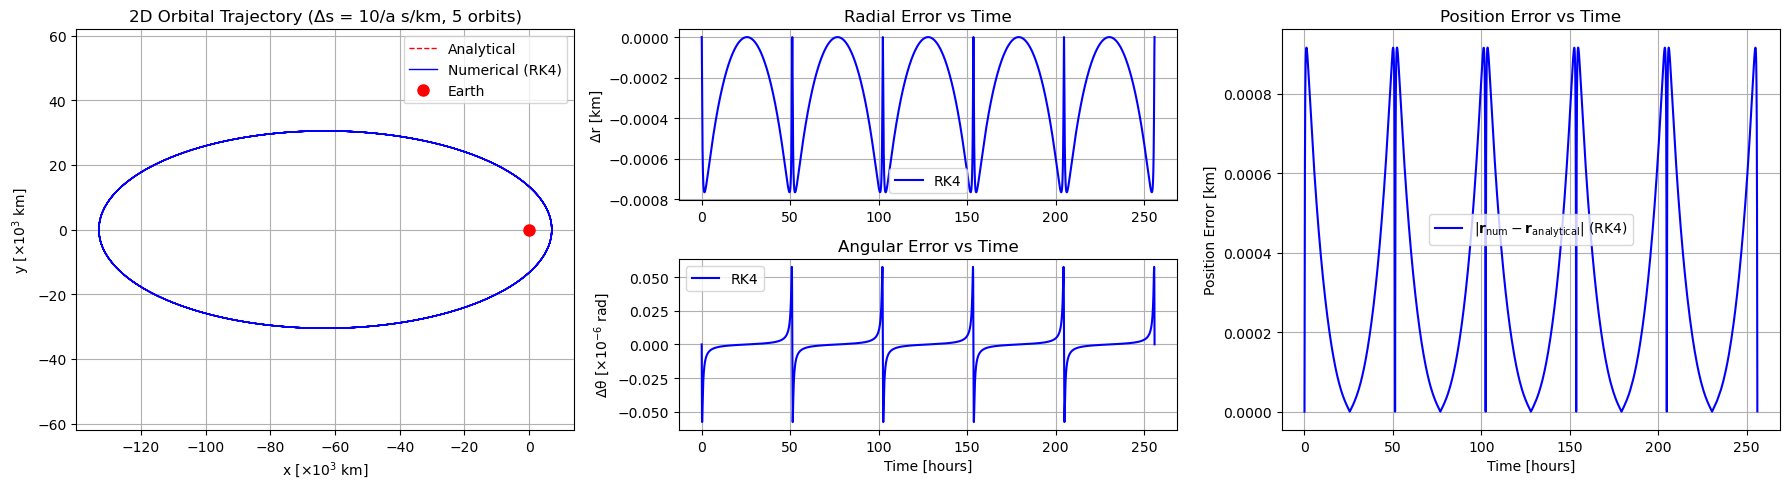

In [46]:
fig = plt.figure(figsize=(18, 5))
gs = fig.add_gridspec(2, 3)  # 2 rows, 3 columns total

# --- Plot 1: Trajectory comparison (spans both rows in column 0)
ax1 = fig.add_subplot(gs[:, 0])
ax1.plot(x_ks_analytical / 1e3, y_ks_analytical / 1e3, '--', label='Analytical', color='red', linewidth=1)
ax1.plot(x_ks_rk4 / 1e3, y_ks_rk4 / 1e3, label='Numerical (RK4)', color='blue', linewidth=1)
# ax1.plot(x_ks_adams, y_ks_adams, label='Numerical (Adams)', color='green', linewidth=1)
ax1.plot(0, 0, 'ro', label='Earth', markersize=8)
ax1.set_xlabel('x [$\\times 10^3$ km]')
ax1.set_ylabel('y [$\\times 10^3$ km]')
ax1.set_title(f'2D Orbital Trajectory (Δs = {dt}/a s/km, {n_orbits} orbits)')
ax1.legend()
ax1.axis('equal')
ax1.grid(True)

# --- Plot 2a: Δr vs Time (top-right)
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(t_vals_ks / 3600, r_vec_norm_ks_rk4 - r_vec_norm_ks_analytical, label='RK4', color='blue')
# ax2.plot(t_vals_ks / 3600, r_vec_norm_ks_adams - r_vec_norm_ks_analytical, label='Adams', color='green')
ax2.set_ylabel('Δr [km]')
ax2.set_title('Radial Error vs Time')
ax2.legend()
ax2.grid(True)

# --- Plot 2b: Δθ vs Time (bottom-right)
ax3 = fig.add_subplot(gs[1, 1])
ax3.plot(t_vals_ks / 3600, (np.mod(theta_ks_rk4 - theta_ks_analytical + np.pi, 2*np.pi) - np.pi) * 1e6, label='RK4', color='blue')
# ax3.plot(t_vals_ks / 3600, (np.mod(theta_ks_adams - theta_ks_analytical + np.pi, 2*np.pi) - np.pi) * 1e6, label='Adams', color='green')
ax3.set_xlabel('Time [hours]')
ax3.set_ylabel('Δθ [$\\times 10^{-6}$ rad]')
ax3.set_title('Angular Error vs Time')
ax3.legend()
ax3.grid(True)

# --- Plot 3: Position error vs Time (spans both rows in column 2)
ax4 = fig.add_subplot(gs[:, 2])
ax4.plot(t_vals_ks / 3600, np.linalg.norm(r_vec_ks_rk4 - r_vec_ks_analytical, axis=1),
         label=r"$|\mathbf{r}_\mathrm{num} - \mathbf{r}_\mathrm{analytical}|$ (RK4)", color='blue')
# ax4.plot(t_vals_ks / 3600, np.linalg.norm(r_vec_ks_adams - r_vec_ks_analytical, axis=1),
#          label=r"$|\mathbf{r}_\mathrm{num} - \mathbf{r}_\mathrm{analytical}|$ (Adams)", color='green')
ax4.set_xlabel('Time [hours]')
ax4.set_ylabel('Position Error [km]')
ax4.set_title('Position Error vs Time')
ax4.legend()
ax4.grid(True)

# --- Final layout
plt.tight_layout()
plt.show()

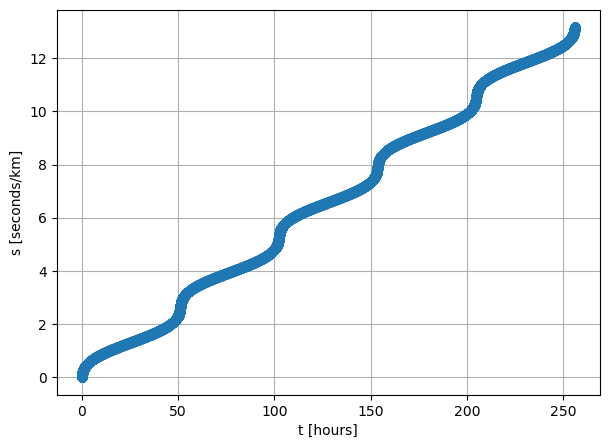

In [47]:
plt.figure(figsize=(7, 5))
plt.plot(t_vals_ks / 3600, s_vals, marker='o', linestyle='-')
plt.xlabel('t [hours]')
plt.ylabel('s [seconds/km]')
plt.grid(True)
plt.show()